# Ensemble Methods: Bagging & AdaBoost

## What Are Ensemble Methods?

An ensemble combines many **weak learners**  (models that perform only slightly better than random guessing) into a **strong learner** that is accurate, stable, and generalizes well. Two fundamentally different strategies exist:

**Bagging** trains all learners independently on different bootstrap samples and combines them by majority vote. Diversity comes from data variation. It reduces **variance**.

**Boosting** trains learners sequentially. Each new learner is forced to pay extra attention to the mistakes of the previous ensemble. It reduces **bias** and **variance**.

## The Core AdaBoost Idea

At each round, misclassified samples receive higher weights. The next weak learner is trained on this reweighted dataset, so it concentrates on the hard cases. The final prediction is a weighted vote where accurate learners count more:

$$H(\mathbf{x}) = \text{sign}\!\left(\sum_{t=1}^T \alpha_t h_t(\mathbf{x})\right), \qquad \alpha_t = \frac{1}{2}\ln\!\frac{1-\epsilon_t}{\epsilon_t}$$

A weak learner with error $\epsilon_t < 0.5$ gets positive weight $\alpha_t > 0$; the better the learner, the more it counts.

## 1. Setup & Data Download

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request, os, sys

sys.path.insert(0, os.path.abspath('../../../src'))
from mlpackage.supervised_learning.ensemble import BaggingClassifier, AdaBoostClassifier
from mlpackage.supervised_learning.decision_tree import DecisionTree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

CSV_PATH = 'banknote_authentication.csv'
if not os.path.exists(CSV_PATH):
    url = ('https://archive.ics.uci.edu/ml/machine-learning-databases/'
           '00267/data_banknote_authentication.txt')
    urllib.request.urlretrieve(url, CSV_PATH)
    print('Dataset downloaded.')
else:
    print('Dataset already present.')

Dataset downloaded.


## 2. Data Exploration

In [2]:
col_names = ['variance', 'skewness', 'curtosis', 'entropy', 'class']
df = pd.read_csv(CSV_PATH, header=None, names=col_names)
feature_cols = col_names[:-1]

print('Shape:', df.shape)
print('\nClass distribution:')
print(df['class'].value_counts().rename({0:'Genuine', 1:'Forged'}))
df.describe()

Shape: (1372, 5)

Class distribution:
class
Genuine    762
Forged     610
Name: count, dtype: int64


,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


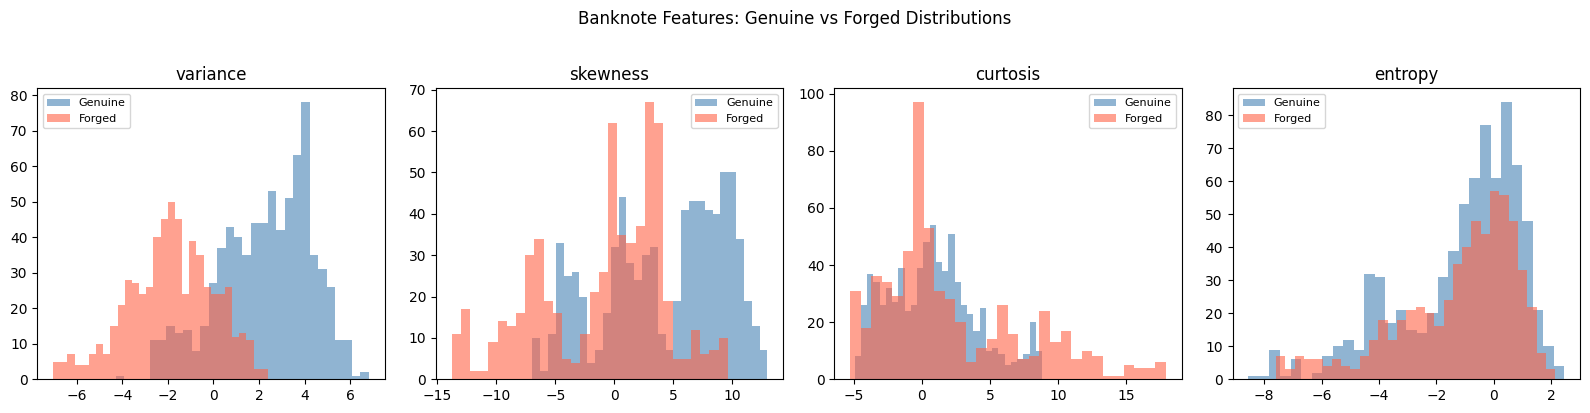

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, feature_cols):
    for label, name, color in [(0,'Genuine','steelblue'),(1,'Forged','tomato')]:
        ax.hist(df[df['class']==label][col], bins=30,
                alpha=0.6, label=name, color=color)
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle('Banknote Features: Genuine vs Forged Distributions', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Each plot above shows the distribution of one wavelet-based image feature, split by banknote class (genuine=blue, forged=red).

- 'variance' and 'skewness': the two classes separate well but overlap in the middle. Thus, a single threshold (stump) will not perfectly classify all samples. This is actually great for boosting: the first stump gets the easy cases right, and subsequent stumps focus on the ambiguous overlap region.
- 'curtosis' and 'entropy': weaker separation, these features contribute less individually but add value in combination with others.

## 3. Preprocessing

In [ ]:
X = df[feature_cols].values
y = df['class'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale for Bagging (base estimator uses threshold splits, so not strictly
# needed, but included for fair comparison with distance-sensitive methods)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape}  |  Test: {X_test_s.shape}')

Train: (1097, 4)  |  Test: (275, 4)


## 4. Baseline — Single Decision Stump

In [5]:
stump = DecisionTree(task='classification', max_depth=1)
stump.fit(X_train_s, y_train)
stump_acc = stump.score(X_test_s, y_test)
print(f'Single stump (depth=1) test accuracy: {stump_acc:.4f}')

deep_tree = DecisionTree(task='classification', max_depth=None)
deep_tree.fit(X_train_s, y_train)
print(f'Deep tree (unlimited) test accuracy:  {deep_tree.score(X_test_s, y_test):.4f}')

Single stump (depth=1) test accuracy: 0.8327
Deep tree (unlimited) test accuracy:  0.9745


## 5. Bagging

In [9]:
from tqdm import tqdm

n_range = [1, 5, 10, 20, 50, 100, 150]
bag_accs = []

for n in tqdm(n_range):
    bag = BaggingClassifier(n_estimators=n, random_state=42)
    bag.fit(X_train_s, y_train)
    bag_accs.append(bag.score(X_test_s, y_test))

best_bag = BaggingClassifier(n_estimators=100, random_state=42)
best_bag.fit(X_train_s, y_train)

print(f'Best Bagging accuracy (100 estimators): {best_bag.score(X_test_s, y_test):.4f}')
print(f'OOB score: {best_bag.oob_score_:.4f}')

100%|██████████| 7/7 [29:52<00:00, 256.12s/it]


Best Bagging accuracy (100 estimators): 0.9927
OOB score: 0.9872


## 6. AdaBoost

In [10]:
ada = AdaBoostClassifier(n_estimators=150, learning_rate=0.5, max_depth=1)
ada.fit(X_train_s, y_train)
print(f'AdaBoost accuracy (150 rounds): {ada.score(X_test_s, y_test):.4f}')
print(f'Number of rounds completed:     {len(ada.estimators_)}')

AdaBoost accuracy (150 rounds): 0.9964
Number of rounds completed:     150


## 7. AdaBoost Staged Accuracy — Watching It Learn

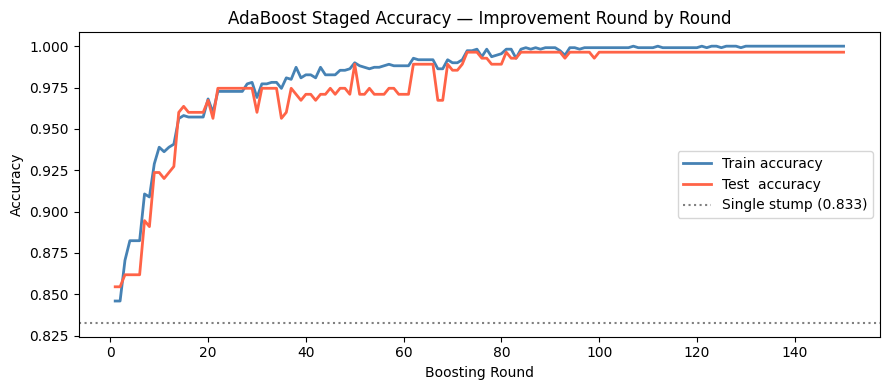

In [11]:
staged_test  = list(ada.staged_score(X_test_s, y_test))
staged_train = list(ada.staged_score(X_train_s, y_train))
rounds = range(1, len(staged_test) + 1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(rounds, staged_train, label='Train accuracy', color='steelblue', linewidth=2)
ax.plot(rounds, staged_test,  label='Test  accuracy', color='tomato',    linewidth=2)
ax.axhline(stump_acc, color='gray', linestyle=':', linewidth=1.5,
           label=f'Single stump ({stump_acc:.3f})')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Accuracy')
ax.set_title('AdaBoost Staged Accuracy — Improvement Round by Round')
ax.legend()
plt.tight_layout()
plt.show()

Each point on the x-axis is one additional decision stump added to the ensemble.
The y-axis shows cumulative accuracy after that many stumps have been combined.

Round 1 (gray dotted baseline): Only one stump; the accuracy equals a single weak learner.

Early rounds: Accuracy rises steeply and each new stump corrects the easiest remaining errors. The samples near the middle of the feature histograms (ambiguous overlap zone discussed in Section 2) get extra weight and the next stump learns to handle them.

Later rounds: The curve flattens as the remaining errors are harder (samples genuinely close to the decision boundary) and eventually stochastic.

Train vs Test gap: If train accuracy approaches 1.0 but test starts dropping, boosting has overfit, it memorized training noise. Unlike bagging, AdaBoost can overfit, especially on noisy data or with many rounds.

## 8. AdaBoost Learner Weights & Errors

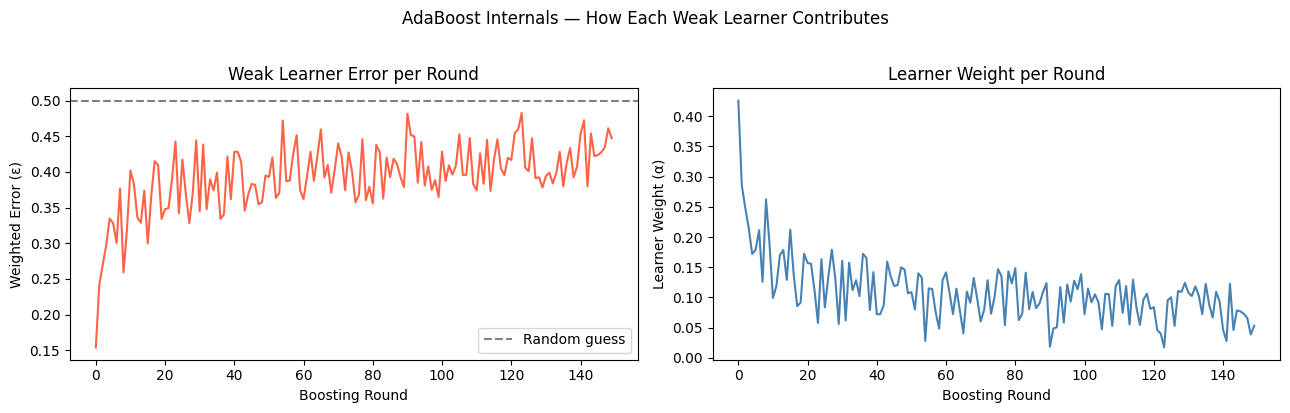

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(ada.estimator_errors_, color='tomato', linewidth=1.5)
axes[0].axhline(0.5, color='gray', linestyle='--', label='Random guess')
axes[0].set_xlabel('Boosting Round')
axes[0].set_ylabel('Weighted Error (ε)')
axes[0].set_title('Weak Learner Error per Round')
axes[0].legend()

axes[1].plot(ada.estimator_weights_, color='steelblue', linewidth=1.5)
axes[1].set_xlabel('Boosting Round')
axes[1].set_ylabel('Learner Weight (α)')
axes[1].set_title('Learner Weight per Round')

plt.suptitle('AdaBoost Internals — How Each Weak Learner Contributes',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

The left plot represents weighted error per round. Early rounds have low error (<0.5) because the data is not yet up-weighted on the hard cases. As boosting proceeds, the reweighting concentrates samples near the decision boundary, making each new stump's job harder, so errors tend to increase over rounds. Any round with error >= 0.5 would be discarded (stopping condition).

The plot on the right shows the learner weight (α) per round, α = 0.5 * ln((1 - ε) / ε). A learner with low error gets large α (high vote); a learner with error close to 0.5 gets α near 0 (almost no vote). Early, accurate stumps carry more voting power in the final ensemble. Later stumps (harder problems, higher error) contribute less.

Together these plots explain why AdaBoost works: it automatically down-weights the unreliable late-stage learners and amplifies the early accurate ones.

## 9. Full Comparison — Stump vs Bagging vs AdaBoost

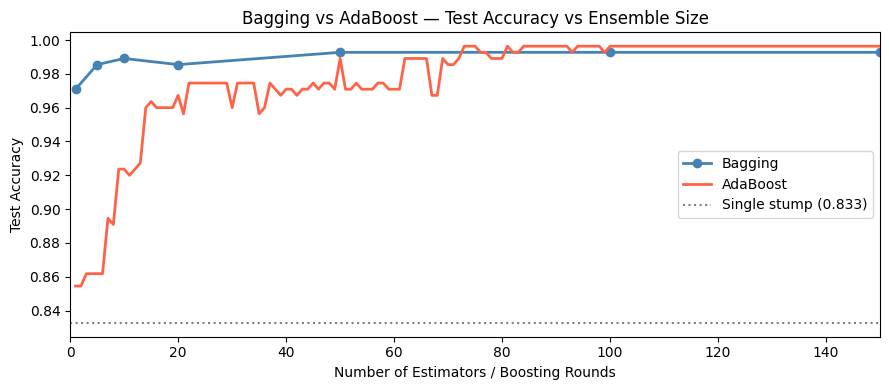

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(n_range, bag_accs, 'o-', label='Bagging', color='steelblue', linewidth=2)
ax.plot(rounds, staged_test, '-', label='AdaBoost', color='tomato', linewidth=2)
ax.axhline(stump_acc, color='gray', linestyle=':', linewidth=1.5,
           label=f'Single stump ({stump_acc:.3f})')
ax.set_xlabel('Number of Estimators / Boosting Rounds')
ax.set_ylabel('Test Accuracy')
ax.set_title('Bagging vs AdaBoost — Test Accuracy vs Ensemble Size')
ax.legend()
ax.set_xlim(0, max(max(n_range), max(rounds)))
plt.tight_layout()
plt.show()

Both methods start from the weak single-stump baseline (gray dotted line) and improve as more learners are added.

Bagging (blue): rises quickly and plateaus. Adding more trees provides diminishing returns once variance is sufficiently reduced. The floor is set by the bias of shallow trees (all trained with the same architecture).

AdaBoost (red): typically steeper initial rise. It actively corrects bias by focusing on misclassified samples, not just reducing variance. However, it can overfit with too many rounds on noisy data.

On this clean dataset (no labeled noise), both methods perform well.
On noisier data, bagging would be more robust while AdaBoost would amplify mislabeled samples and potentially overfit.

## 10. Effect of Learning Rate on AdaBoost

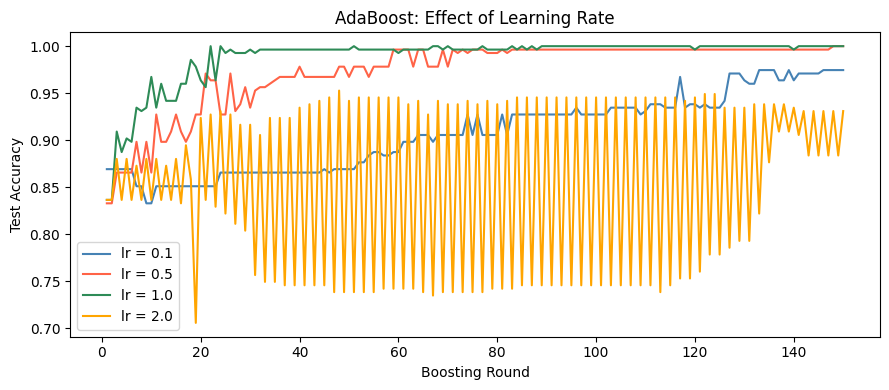

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))

for lr, color in [(0.1,'steelblue'),(0.5,'tomato'),(1.0,'seagreen'),(2.0,'orange')]:
    m = AdaBoostClassifier(n_estimators=150, learning_rate=lr, max_depth=1)
    m.fit(X_train_s, y_train)
    curve = list(m.staged_score(X_test_s, y_test))
    ax.plot(range(1, len(curve)+1), curve, label=f'lr = {lr}', color=color)

ax.set_xlabel('Boosting Round')
ax.set_ylabel('Test Accuracy')
ax.set_title('AdaBoost: Effect of Learning Rate')
ax.legend()
plt.tight_layout()
plt.show()

Learning rate shrinks the contribution of each weak learner: α_effective = learning_rate × α_t.

- Low lr (0.1, blue): slow but stable. Needs more rounds to converge but is less likely to overfit. Best for noisy datasets.
- Moderate lr (0.5, red): faster convergence, good balance.
- High lr (1.0, green): fast convergence; can start overfitting if rounds continue past the peak.
- Very high lr (2.0, orange): unstable. Large steps cause the ensemble to overshoot optimal weights, and accuracy may fluctuate or drop.

So the general rule is: lower learning rate + more rounds usually beats higher learning rate + fewer rounds (same principle as gradient descent).

## 11. Final Evaluation

Model                 Train Acc   Test Acc
------------------------------------------
Single Stump             0.8423     0.8327
Bagging (100)            1.0000     0.9927
AdaBoost (100)           0.9991     0.9964

AdaBoost Classification Report:
              precision    recall  f1-score   support

     Genuine       1.00      0.99      1.00       153
      Forged       0.99      1.00      1.00       122

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275



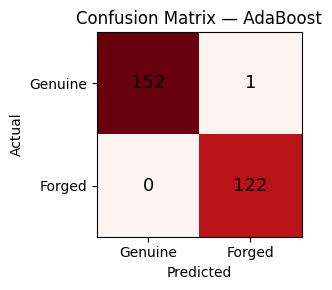

In [16]:
final_ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.5, max_depth=1)
final_ada.fit(X_train_s, y_train)

models = {
    'Single Stump': stump,
    'Bagging (100)': best_bag,
    'AdaBoost (100)': final_ada
}

print(f'{"Model":<20} {"Train Acc":>10} {"Test Acc":>10}')
print('-' * 42)
for name, m in models.items():
    tr = m.score(X_train_s, y_train)
    te = m.score(X_test_s, y_test)
    print(f'{name:<20} {tr:>10.4f} {te:>10.4f}')

print('\nAdaBoost Classification Report:')
y_pred = final_ada.predict(X_test_s)
print(classification_report(y_test, y_pred,
      target_names=['Genuine','Forged']))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4, 3))
ax.imshow(cm, cmap='Reds')
ax.set_xticks([0,1]); ax.set_xticklabels(['Genuine','Forged'])
ax.set_yticks([0,1]); ax.set_yticklabels(['Genuine','Forged'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — AdaBoost')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=13)
plt.tight_layout(); plt.show()

## 12. Key Takeaways

- The **staged accuracy curve** is AdaBoost's most important diagnostic: a rising curve that plateaus is healthy. A curve that rises then falls signals overfitting, reduce rounds or lower the learning rate.
- The **learner weights and errors plot** reveals AdaBoost's internals: early stumps are accurate (low ε, high α) and carry more of the final vote. Later stumps face harder reweighted problems and contribute less.
- **Bagging vs AdaBoost convergence**: bagging plateaus once variance is reduced; AdaBoost's sequential bias reduction continues to squeeze out accuracy. On clean data AdaBoost usually wins; on noisy data, bagging is safer.
- The **learning rate controls step size** in weight updates. Small lr is more stable but requires more rounds (classic speed/stability trade-off).
- Both methods significantly outperform a single weak learner, demonstrating the core principle of ensemble learning: "combining many different models often gives better results than relying on just one".

## Why Emsemble Methods?

The banknote dataset has 4 numerical features (no missing values, no encoding needed) and is challenging enough that a single decision stump (depth=1) makes meaningful errors. Thus, AdaBoost's sequential improvement is clearly visible in the staged accuracy curve. The dataset is small enough to train many rounds quickly.

This dataset is ideal for comparing bagging and boosting because:

- Both methods in this implementation handle binary labels directly (AdaBoost requires it; Bagging works with any classifier).
- With 4 wavelet-based image features, the data is not trivially separable by a single stump but is learnable by shallow trees, making AdaBoost's sequential improvement clearly visible.
- No missing values or encoding needed, so all notebook space goes toward understanding the algorithms rather than preprocessing.
- AdaBoost's `staged_score` method shows accuracy building round by round, making the boosting effect directly observable.